# Running MEEP Simulations

[MEEP](https://meep.readthedocs.io/) is an open-source FDTD electromagnetic simulator. This notebook demonstrates using the `gsim.meep` API to run an S-parameter simulation on a photonic Y-branch.

**Requirements:**

- UBC PDK: `uv pip install ubcpdk`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from UBC PDK

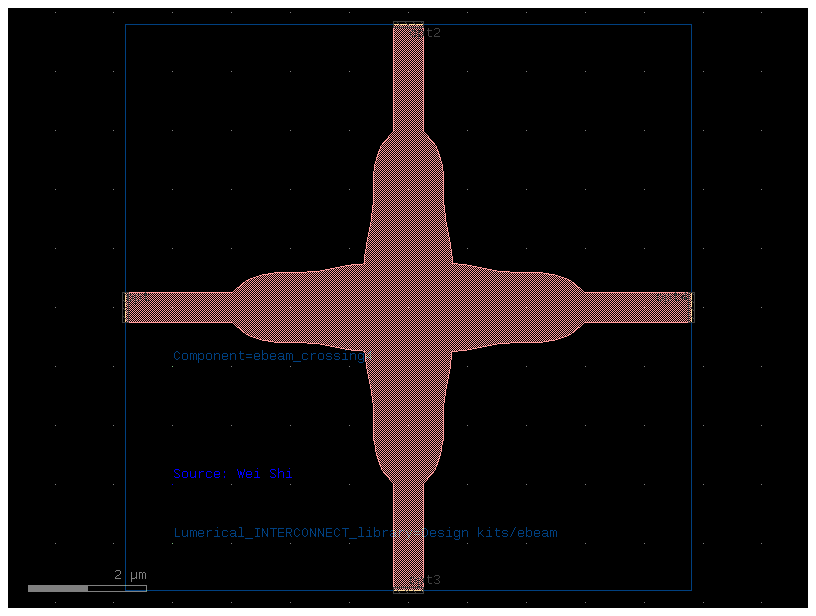

In [1]:
from ubcpdk import PDK, cells

PDK.activate()

c = cells.ebeam_crossing4()

c

### Configure and run simulation

In [ ]:
from gsim import meep
from gsim.common.stack import get_stack
from gsim.meep.models.api import Material

stack = get_stack()  # auto-detects active PDK

sim = meep.Simulation()

sim.geometry(component=c, stack=stack, z_crop="auto")
sim.materials = {
    "si": Material(refractive_index=3.47),
    "SiO2": Material(refractive_index=1.44),
}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.04)
sim.monitors = ["o1", "o2", "o3", "o4"]
sim.domain(pml=1.0, margin=0.5)
sim.solver(resolution=20, save_animation=True, verbose_interval=5.0)
sim.num_freqs = 51
sim.solver.stop_when_energy_decayed()

print(sim.validate_config())

xsxs

simulation.py:713: UserWarning: Material 'Aluminum' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('Aluminum', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:713: UserWarning: Material 'TiN' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('TiN', refractive_index=...) to include it.
  material_data = resolve_materials(
simulation.py:713: UserWarning: Material 'passive' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('passive', refractive_index=...) to include it.
  material_data = resolve_materials(


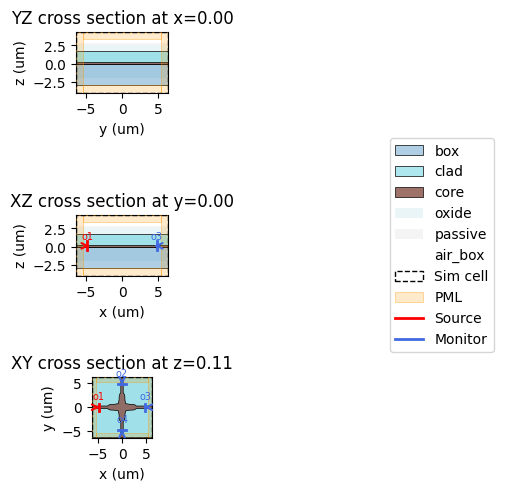

In [3]:
sim.plot_2d(slices="xyz")

### Run simulation on cloud

In [4]:
# Run on GDSFactory+ cloud
result = sim.run()

  meep-a1453ebb  completed  3m 15s


Extracting results.tar.gz...


Downloaded 207 files to sim-data-meep-a1453ebb


In [5]:
result.plot_interactive()

In [6]:
result.plot_interactive(phase=True)

In [7]:
result.show_animation()